In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

In [2]:
df_1896 = pl.read_csv("tables/medals_1896-2022.csv")
df_2024 = pl.read_csv("tables/medals_2024.csv")

In [4]:
df_1896 = df_1896.filter(pl.col("medal").is_not_null())

In [5]:
df_dedup = (
    df_1896
    .unique(subset=["edition_id", "event", "country_noc", "medal"])
)

In [6]:
df_summer = df_dedup.filter(pl.col("edition").str.contains("Summer"))
df_winter  = df_dedup.filter(pl.col("edition").str.contains("Winter"))

In [7]:
df_summer = (
    df_summer
    .pivot(on="medal", index="country_noc", values="medal", aggregate_function="len")
    .fill_null(0)
)

In [8]:
df_winter = (
    df_winter
    .pivot(on="medal", index="country_noc", values="medal", aggregate_function="len")
    .fill_null(0)
)

In [9]:
medal_cols = ["Gold", "Silver", "Bronze"]

df_summer = df_summer.with_columns(
    pl.sum_horizontal(medal_cols).alias("Total")
)
df_winter = df_winter.with_columns(
    pl.sum_horizontal(medal_cols).alias("Total")
)

In [10]:
df_2024_medals = df_2024.with_columns(pl.col("Gold Medal").alias("Gold"),
                               pl.col("Silver Medal").alias("Silver"),
                               pl.col("Bronze Medal").alias("Bronze"),
                               ).drop(["Gold Medal", "Silver Medal", "Bronze Medal", "country", "country_long"],
                               ).rename({"country_code": "country_noc"})

In [11]:
df_temp = (
    df_summer.join(df_2024_medals, on="country_noc", how="full", coalesce=True)
    .fill_null(0))

In [13]:
df_total_summer = df_temp.with_columns(
        (pl.col("Gold") + pl.col("Gold_right")).alias("Gold"),
        (pl.col("Silver") + pl.col("Silver_right")).alias("Silver"),
        (pl.col("Bronze") + pl.col("Bronze_right")).alias("Bronze"),
        (pl.col("Gold") + pl.col("Silver") + pl.col("Bronze")).alias("Total"),
    ).drop(["Gold_right", "Silver_right", "Bronze_right", "Total_right"])

In [14]:
df_total_summer = df_total_summer.with_columns((pl.col("Gold") + pl.col("Silver") + pl.col("Bronze")).alias("Total"))

In [16]:
df_total_summer = df_total_summer.rename({
    "Gold":   "Gold_Summer",
    "Silver": "Silver_Summer",
    "Bronze": "Bronze_Summer",
    "Total":  "Total_Summer",
})

df_winter = df_winter.rename({
    "Gold":   "Gold_Winter",
    "Silver": "Silver_Winter",
    "Bronze": "Bronze_Winter",
    "Total":  "Total_Winter",
})

In [17]:
df_full =(df_total_summer.join(df_winter, on="country_noc", how="full", coalesce=True)
    .fill_null(0))

In [18]:
df_summer_rank = (
    df_full
    .select(["country_noc", "Gold_Summer", "Silver_Summer", "Bronze_Summer", "Total_Summer"])
    .sort("Total_Summer", descending=True)
)
df_summer_rank.head(10)

country_noc,Gold_Summer,Silver_Summer,Bronze_Summer,Total_Summer
str,i64,i64,i64,i64
"""USA""",1100,874,775,2749
"""URS""",389,311,290,990
"""GBR""",301,341,335,977
"""FRA""",243,279,301,823
"""GER""",237,271,294,802
"""CHN""",286,218,191,695
"""ITA""",234,206,228,668
"""AUS""",179,189,226,594
"""JPN""",189,161,186,536


In [19]:
df_winter_rank = (
    df_full
    .select(["country_noc", "Gold_Winter", "Silver_Winter", "Bronze_Winter", "Total_Winter"])
    .sort("Total_Winter", descending=True)
)
df_winter_rank.head(10)

country_noc,Gold_Winter,Silver_Winter,Bronze_Winter,Total_Winter
str,u32,u32,u32,u32
"""NOR""",147,134,123,404
"""USA""",106,118,92,316
"""GER""",111,103,70,284
"""AUT""",70,88,91,249
"""CAN""",76,72,74,222
"""URS""",77,56,58,191
"""SWE""",65,51,60,176
"""FIN""",45,65,65,175
"""SUI""",63,47,56,166


In [20]:
df_overall_rank = (
    df_full
    .with_columns(
        (pl.col("Gold_Summer")   + pl.col("Gold_Winter")).alias("Gold_Total"),
        (pl.col("Silver_Summer") + pl.col("Silver_Winter")).alias("Silver_Total"),
        (pl.col("Bronze_Summer") + pl.col("Bronze_Winter")).alias("Bronze_Total"),
        (pl.col("Total_Summer")  + pl.col("Total_Winter")).alias("Total_Geral"),
    )
    .select(["country_noc", "Gold_Total", "Silver_Total", "Bronze_Total", "Total_Geral"])
    .sort("Total_Geral", descending=True)
)
df_overall_rank.head(10)

country_noc,Gold_Total,Silver_Total,Bronze_Total,Total_Geral
str,i64,i64,i64,i64
"""USA""",1206,992,867,3065
"""URS""",466,367,348,1181
"""GER""",348,374,364,1086
"""GBR""",314,346,352,1012
"""FRA""",284,321,356,961
"""ITA""",276,249,284,809
"""CHN""",308,249,214,771
"""SWE""",208,227,237,672
"""AUS""",186,196,232,614


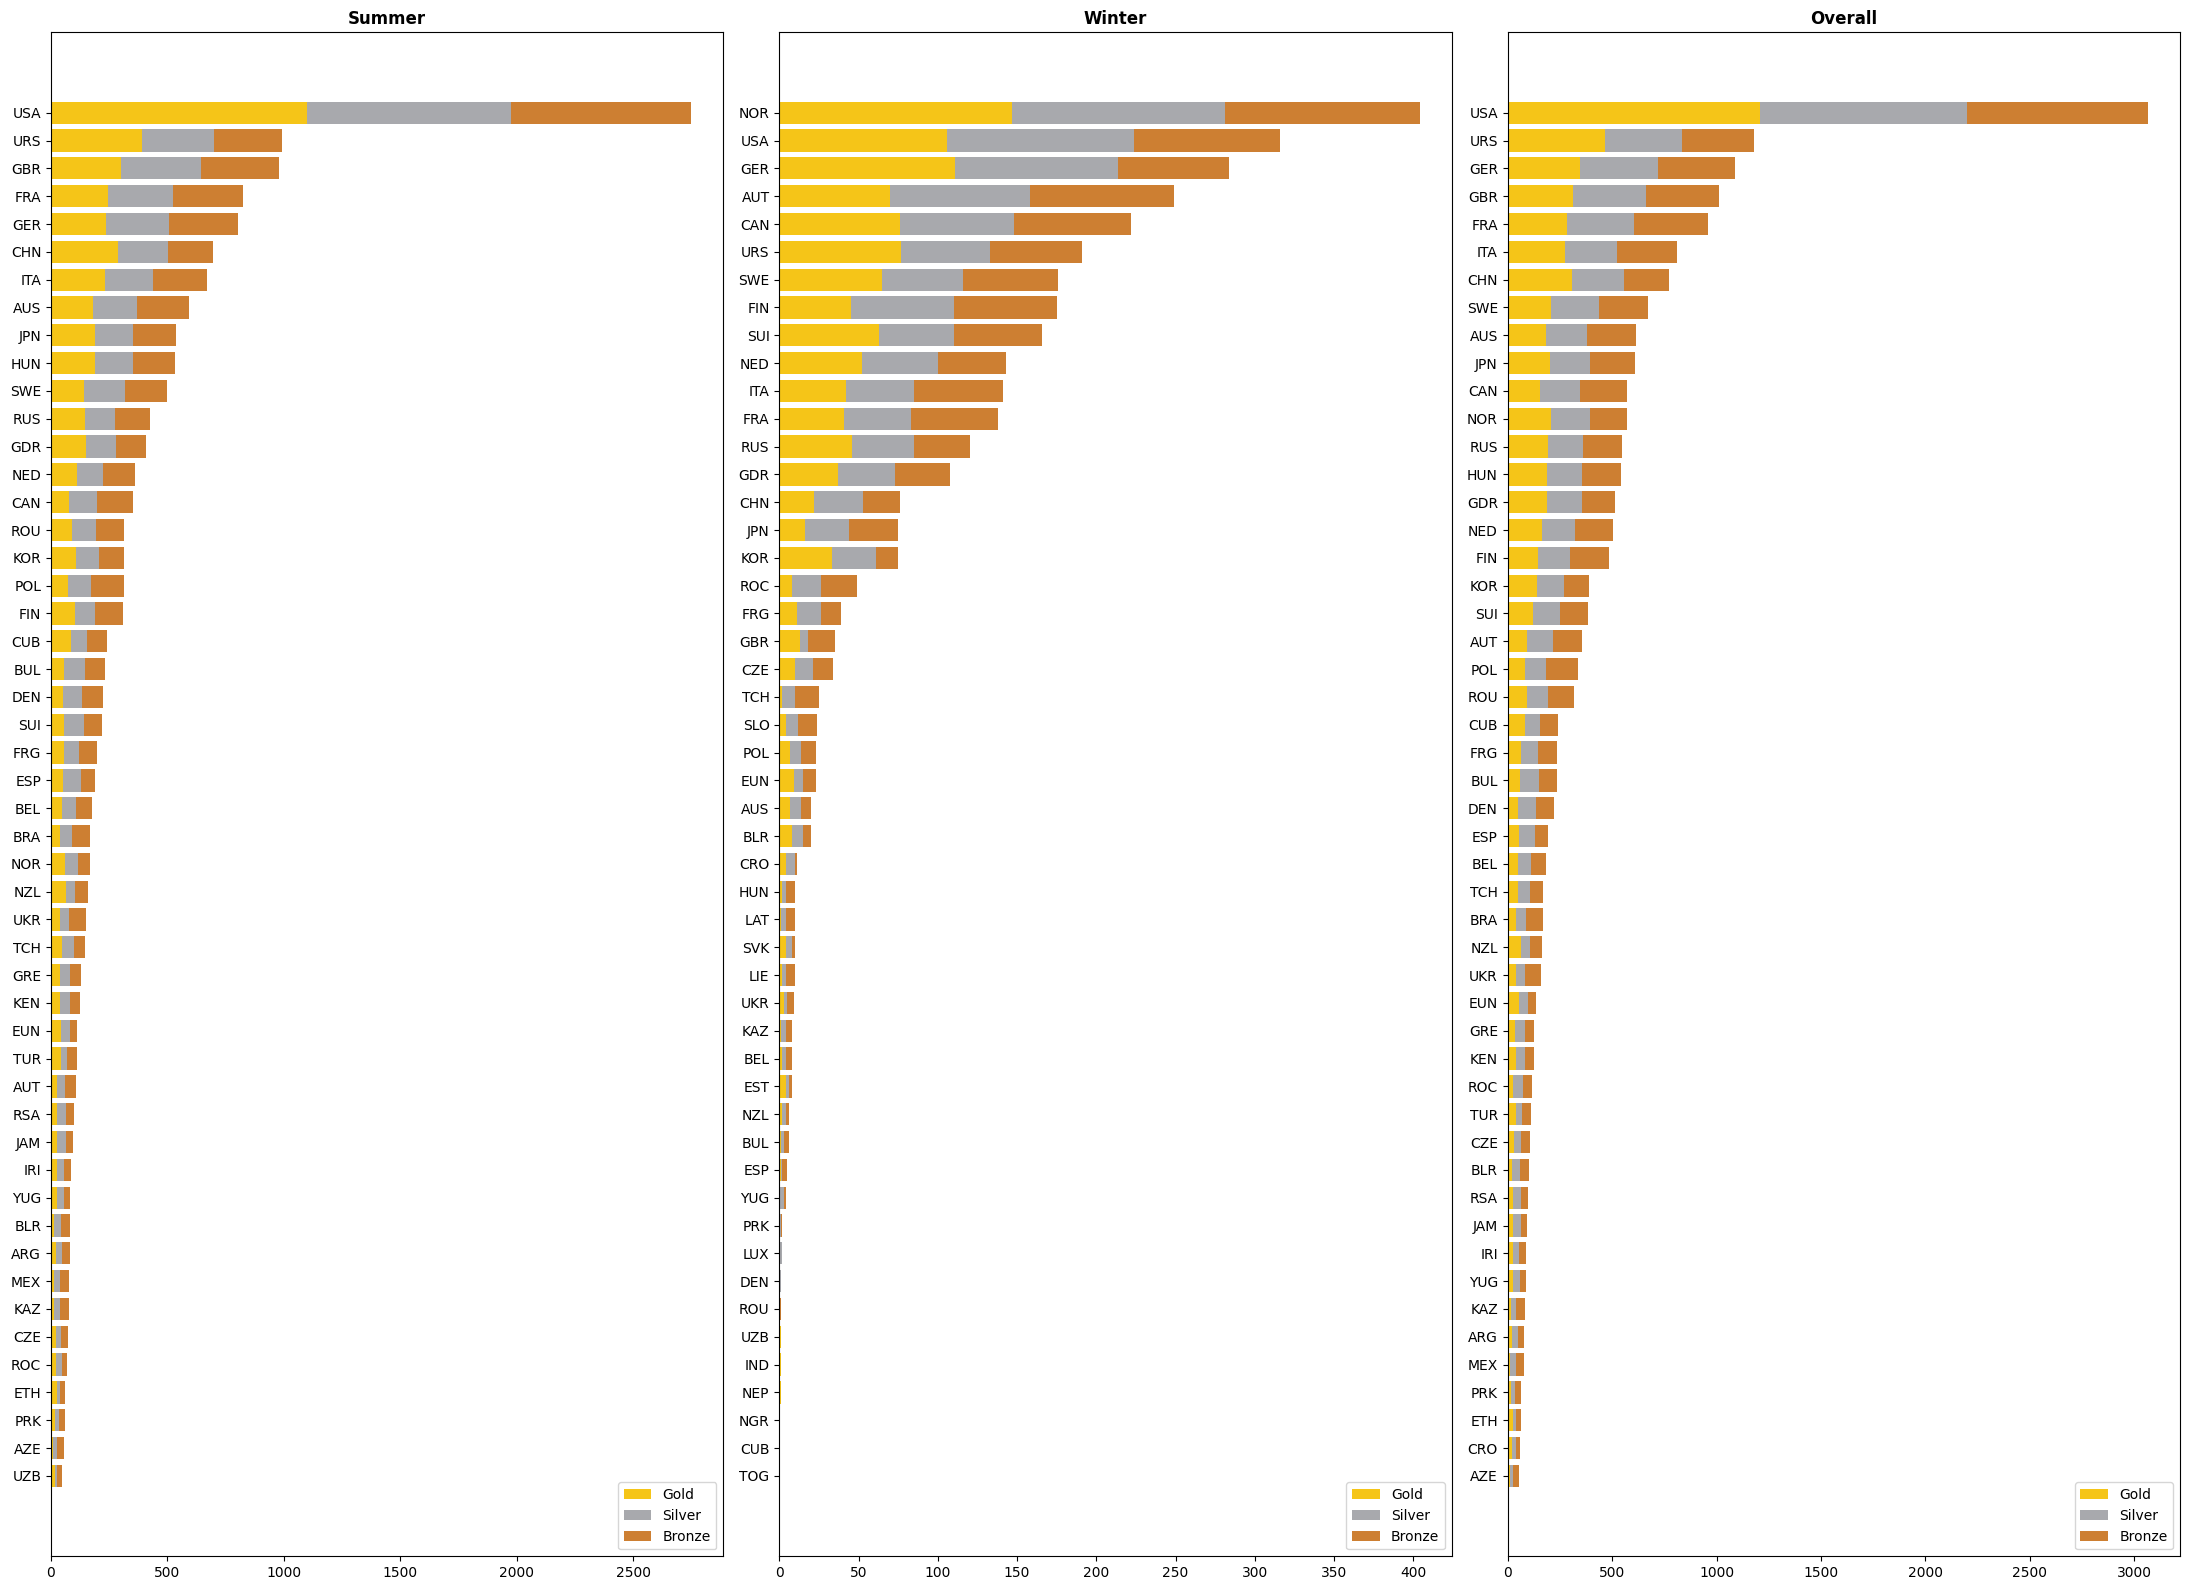

In [21]:
GOLD, SILVER, BRONZE = "#F5C518", "#A8A9AD", "#CD7F32"

fig, axes = plt.subplots(1, 3, figsize=(22, 16))

datasets = [
    (df_summer_rank, "Gold_Summer", "Silver_Summer", "Bronze_Summer", "Total_Summer", "Summer"),
    (df_winter_rank, "Gold_Winter", "Silver_Winter", "Bronze_Winter", "Total_Winter", "Winter"),
    (df_overall_rank, "Gold_Total", "Silver_Total", "Bronze_Total", "Total_Geral", "Overall"),
]

for ax, (df, gold, silver, bronze, _, title) in zip(axes, datasets, strict=False):
    top = df.head(50).reverse()
    countries = top["country_noc"].to_list()
    gold_list = top[gold].to_list()
    silver_list = top[silver].to_list()
    bronze_list = top[bronze].to_list()
    y  = np.arange(len(countries))

    ax.barh(y, gold_list, color=GOLD,   label="Gold")
    ax.barh(y, silver_list, left=gold_list, color=SILVER, label="Silver")
    ax.barh(y, bronze_list, left=np.add(gold_list,silver_list), color=BRONZE, label="Bronze")

    ax.set_yticks(y)
    ax.set_yticklabels(countries)
    ax.set_title(title, fontweight="bold")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("medals_top50.png")
plt.show()